<a href="https://colab.research.google.com/github/Shreyas-coding-master001/Machine_Learning_Seires/blob/main/Basic_Prepocessing/MLDay1ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **First step**

The First step is always very simple you just have to import the necessary libraries and load the dataset for use

In [ ]:
print("hello")

hello


In [ ]:
# Initialization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# df = pd.read_csv("/content/sample_data/insurance.csv");
df = pd.read_csv("/content/insurance.csv");

In [ ]:
print(df.head())    # Understanding columns with first five row values
print(df.shape)     # (column,row) count
print(df.info())    # Basic Information about DataFrames.

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


# **Step 2**

Check if any Null values if prsent either remove it or replace the value using mean, median, mode

In [ ]:
df.isnull().sum() #Tells No.of Null Values

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
#if Null values Present use below to remove all null rows:
df.dropna()

#if wanted to replace the null values can do by either one of them
df["age"].fillna(df["age"].mean())
df["age"].fillna(df["age"].median())
df["age"].fillna(df["age"].mode()[0]) #can be more then one mode return array of modes

df.isnull().sum() #finally check if any null values

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## Step 3: Exploratory Data Analysis (EDA)
EDA is about understanding the data’s story before modelling.
### Learning Goals

Understand distribution of numerical features

Analyse categorical variables

Study relationships between variables

Detect potential outliers or unusual patterns

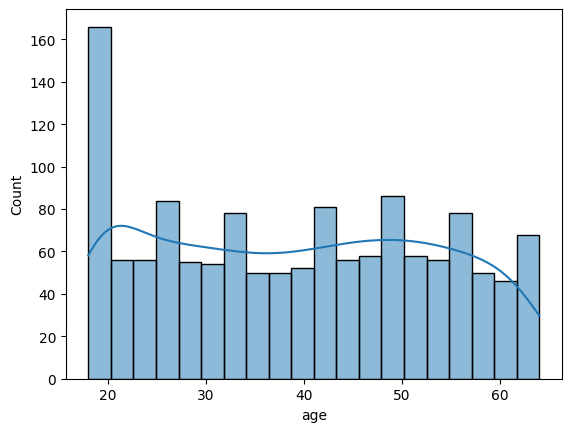

In [ ]:
sns.histplot(data=df, x=df["age"], bins=20, kde=True);
# sns.histplot(df['age'], bins=20);

Using this I can tell age group of people below or around twenty are highly to buy our insurance

<Axes: xlabel='age', ylabel='Density'>

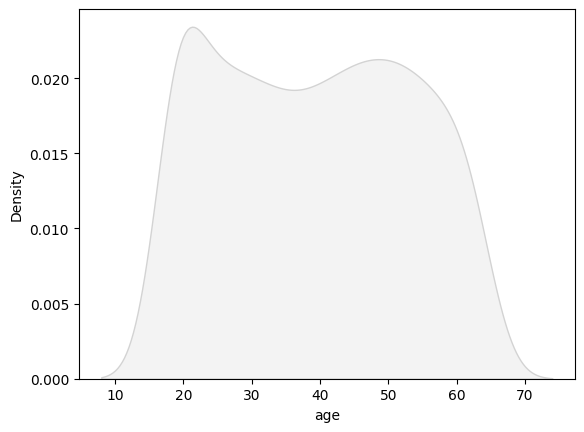

In [ ]:
sns.kdeplot(df["age"], fill=True, color="lightgray")

<Axes: xlabel='bmi', ylabel='Count'>

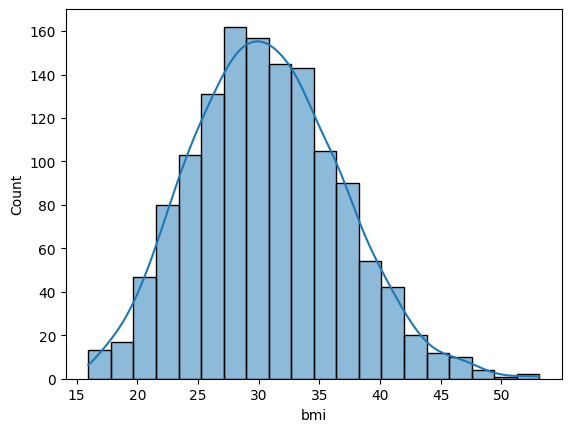

In [ ]:
sns.histplot(df['bmi'], bins=20, kde=True)

<Axes: xlabel='charges', ylabel='Count'>

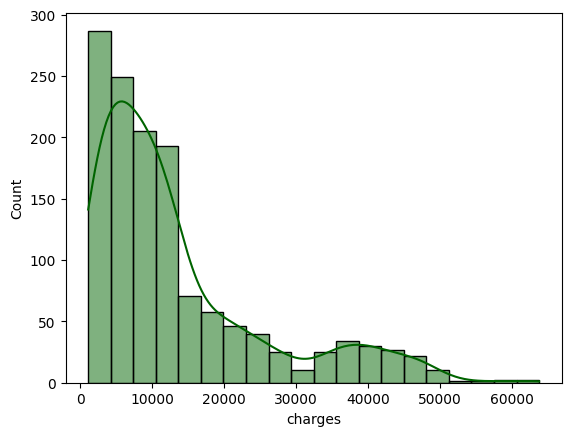

In [ ]:
sns.histplot(df['charges'], bins=20, kde=True, color="darkgreen")

<Axes: xlabel='children', ylabel='Count'>

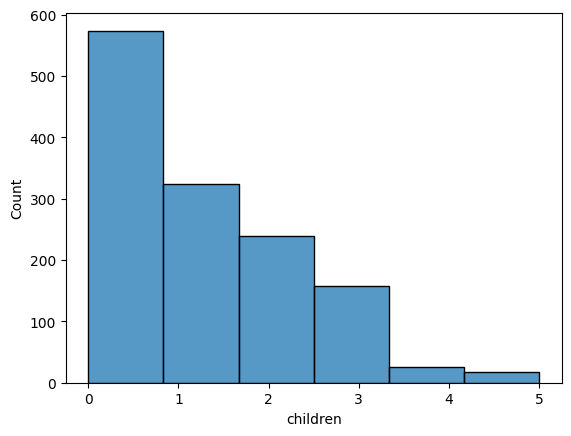

In [ ]:
sns.histplot(df['children'], bins=6)

<Axes: xlabel='children', ylabel='Density'>

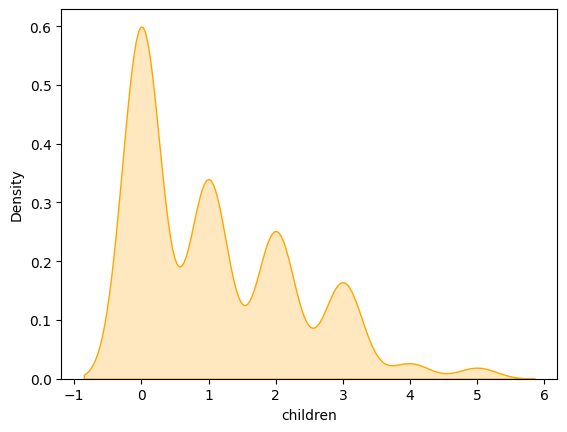

In [ ]:
sns.kdeplot(df['children'], fill=True, color="Orange")

# **Insights and Analysis**

**Denisty Using Histogram and KDE** :

age -> 0-25, bmi -> Good range(25-35), charges -> right-skewed(0-1000), children -> right-skewed : mostly who buys insurence does not have childrens, sex -> equal, smoker -> non-smokers are more to buy insurance, region -> mostly equal but southeast slightly more to buy


**For Categorical Columns**

Get Frequnecy of each category

In [ ]:
cat_col = ["sex", "smoker", "region"]

for col in cat_col:
  print(f"Values Count for Categorical Column {col}")
  print(df[col].value_counts())
  print("-"*40)

Values Count for Categorical Column sex
sex
male      676
female    662
Name: count, dtype: int64
----------------------------------------
Values Count for Categorical Column smoker
smoker
no     1064
yes     274
Name: count, dtype: int64
----------------------------------------
Values Count for Categorical Column region
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
----------------------------------------


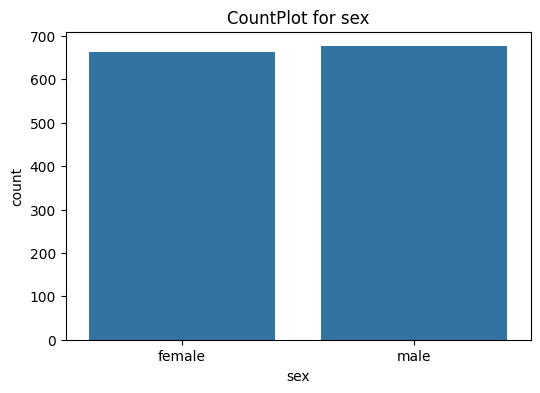

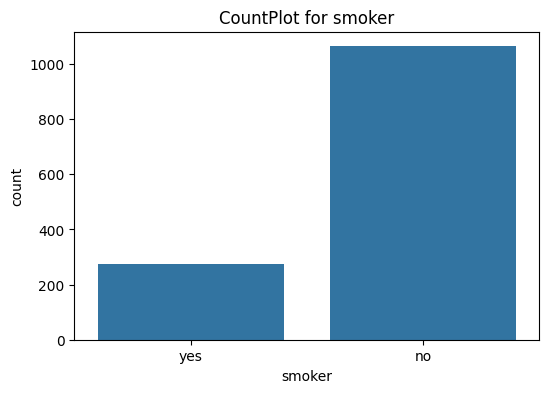

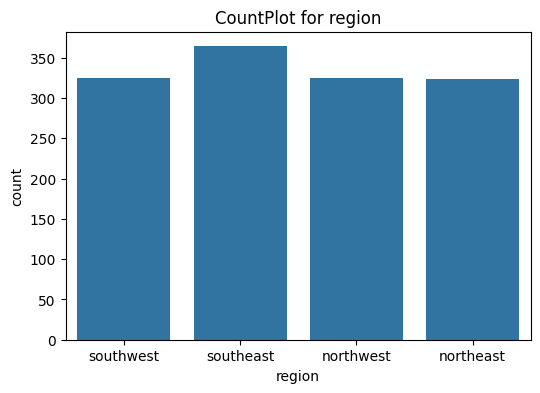

In [ ]:
for col in cat_col:
  plt.figure(figsize=(6,4))
  sns.countplot(x = col, data=df)
  plt.title("CountPlot for {}".format(col))
  plt.show()

<Axes: xlabel='smoker', ylabel='count'>

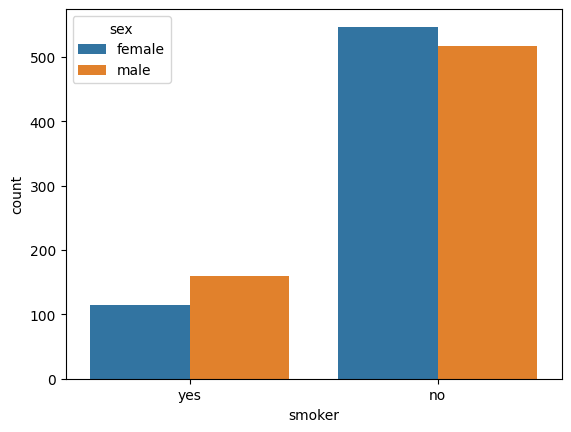

In [ ]:
sns.countplot(x="smoker",hue="sex" ,data=df)

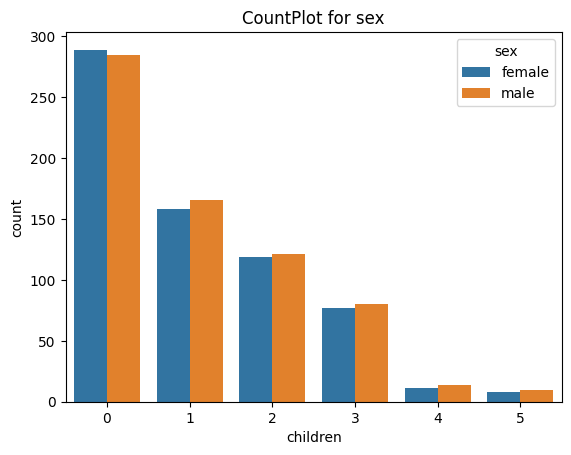

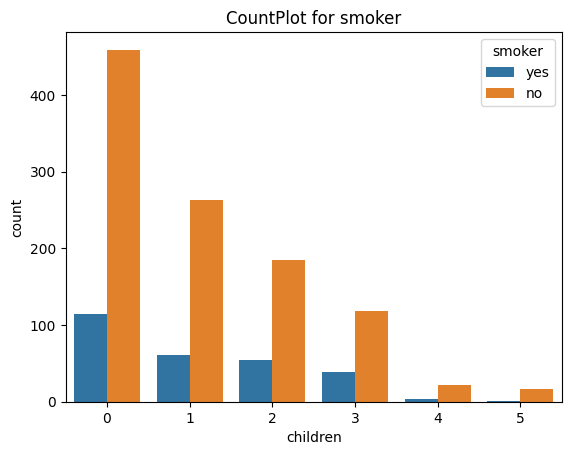

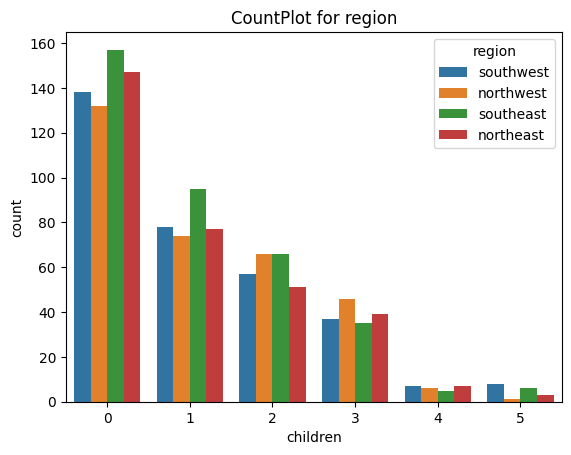

In [ ]:
for col in cat_col:
  sns.countplot(x="children", hue=col, data=df)
  plt.title(f"CountPlot for {col}")
  plt.show()

**Now Try to Find Outlies and Analysis**

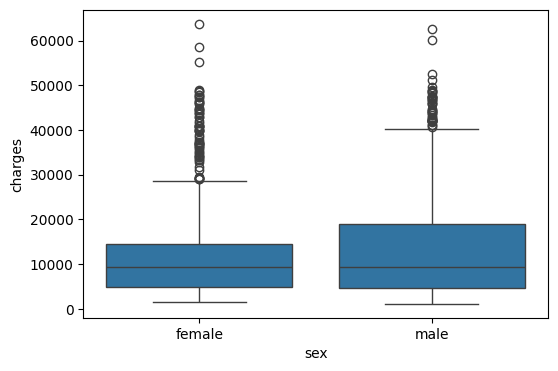

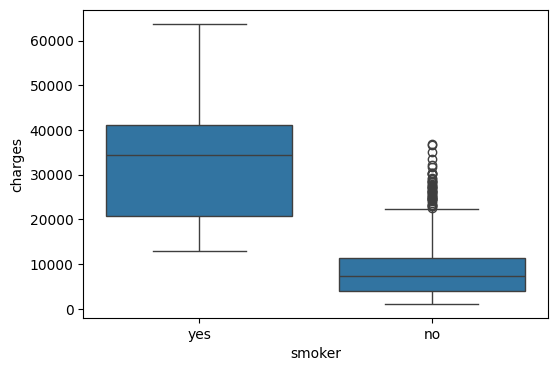

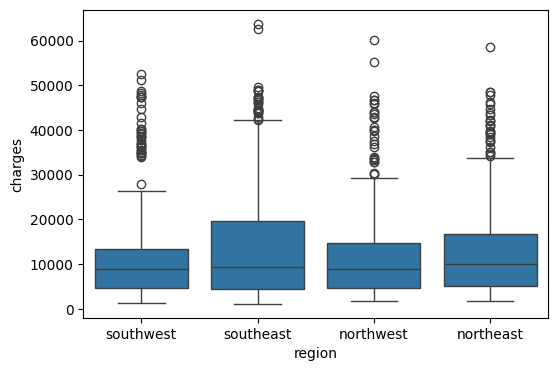

In [ ]:
for col in cat_col:
  plt.figure(figsize=(6,4))
  sns.boxplot(data=df, x=col, y="charges") #Outliers Output Chedna nahi hota
  plt.show()

# **Understanding From BoxPlot**

**`Sex`** -> More Outliers and males in comparition buys little more expensive insurances

**`smoker`** -> Smoking People are more promiant to buy higher rated insurance then non-smokers

**`region`** -> almost good ratio, southeast has slight more in expensive insurance

# **Final Conculsions**


1.   Smokers are more likely to buy expensive insurance

2.   Peoples with zero childrens are majority buy insurance

3.   We are equally but slightly more in southeast area


# Step 5 - Prepare Data for Machine Learning

Once EDA is done,

Convert non-numerical categorical values into numical values using

1.   One-Hot Method
2.   Label encoding


# **One-Hot Encoding** :
It is perform on categorical data which are `unordered`

`example`:
  colors, gender, countries etc

  **`so it will be like`**:
if gender -> male, femal

| gender_male | gender_female |
| ---         | ---           |
| 0 | 1 |
| 1 | 0 |

  

# **Label Encoding** :
It is perform on categorical data which can be `ordered`

`example`:

*   `size of clothes`: small< medium < large < XL ...
*   `School Grade`: high School < Degree < Masters

**`so it will be like`**:

| Degree | Range |
| ---    | ---   |
| High School | 0  |
| Degree    | 1  |
| Masters    | 2   |
| -----| --- |




In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df_encoded = pd.get_dummies(df, columns=["sex"], drop_first=True, dtype=int)
df_encoded = pd.get_dummies(df_encoded, columns=["region"], dtype=int)

In [ ]:
mm_scaler = MinMaxScaler()

df_encoded["age"] = mm_scaler.fit_transform(df[["age"]])
df_encoded["bmi"] = mm_scaler.fit_transform(df[["bmi"]])

In [ ]:
df_encoded

,age,bmi,children,smoker,charges,sex_male,region_northeast,region_northwest,region_southeast,region_southwest
0,0.021739,0.321227,0,yes,16884.92400,0,0,0,0,1
1,0.000000,0.479150,1,no,1725.55230,1,0,0,1,0
2,0.217391,0.458434,3,no,4449.46200,1,0,0,1,0
3,0.326087,0.181464,0,no,21984.47061,1,0,1,0,0
4,0.304348,0.347592,0,no,3866.85520,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,0.695652,0.403820,3,no,10600.54830,1,0,1,0,0
1334,0.000000,0.429379,0,no,2205.98080,0,1,0,0,0
1335,0.000000,0.562012,0,no,1629.83350,0,0,0,1,0
1336,0.065217,0.264730,0,no,2007.94500,0,0,0,0,1
